###Paso 1: Cargar el dataset
Ejecuta el siguiente código para importar las librerías y cargar el dataset:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')


In [ ]:
# Cargar dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)


In [ ]:
# Primeras filas
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Pregunta 1:** ¿Cuántas filas y cuántas columnas tiene el dataset? Usa df.shape para verificar.


In [ ]:
# Respuesta
df.shape

(7043, 22)

###Paso 2: Conocer la estructura del dataset
Ejecuta estos comandos para entender los tipos de datos:


In [ ]:
# Información general del dataset
df.info()

# Tipos de variables
df.dtypes.value_counts()

# Nombres de las columnas
print(df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Pregunta 2:** ¿Cuántas variables numéricas y cuántas categóricas identificas? Escribe 3 ejemplos de cada tipo.

**Respuesta:**
Se identifican 3 variables numéricas (SeniorCitizen, tenure y MonthlyCharges) y 18 variables categóricas (como gender, Contract y PaymentMethod).


**Pregunta 3:** ¿Qué representa cada fila del dataset? ¿Qué representa la columna "Churn"?

**Respuesta:** Cada fila del dataset representa un cliente individual de la empresa, junto con sus características (datos demográficos, servicios contratados y comportamiento). Por otro lado, la columna Churn representa si el cliente abandonó o no el servicio

###Paso 3: Limpieza inicial y- estadísticas descriptivas
Antes de calcular estadísticas, debemos corregir un problema conocido del dataset: la columna TotalCharges contiene valores que no son numéricos (espacios en blanco). Primero limpiamos y luego analizamos:


In [ ]:
# Codificar Churn como numérico para análisis de correlación
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [ ]:
# Estadísticas descriptivas (ahora TotalCharges aparece correctamente)
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,Churn_num
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.265370
std,0.368612,24.559481,30.090047,0.441561
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,0.000000
50%,0.000000,29.000000,70.350000,0.000000
75%,0.000000,55.000000,89.850000,1.000000
max,1.000000,72.000000,118.750000,1.000000


In [ ]:
# Verificar valores nulos en todo el dataset
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Pregunta 4:** ¿Hay valores nulos en el dataset? ¿En qué columna(s)? ¿Cuántos son?

**Respuesta:** No hay valores nulos en el dataset después de la limpieza. Inicialmente, la columna TotalCharges tenía valores faltantes (convertidos a NaN), pero fueron tratados correctamente, quedando 0 valores nulos en todas las columnas.

**Pregunta 5:** ¿Cuál es el promedio de tenure (meses de antigüedad)? ¿Y la mediana? ¿Qué te dice la diferencia entre ambas?

**Respuesta:** El promedio de tenure es aproximadamente 32 meses y la mediana es 29 meses. La diferencia indica que hay algunos clientes con mayor antigüedad que elevan el promedio, lo que sugiere una ligera asimetría hacia la derecha en la distribución.

###Paso 4: Distribución de la variable objetivo
Analiza cómo se distribuye la variable Churn:


In [ ]:
# Distribución de Churn
print(df['Churn'].value_counts())
print(f'\nPorcentaje de churn: {df["Churn"].value_counts(normalize=True)*100}')


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de churn: Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


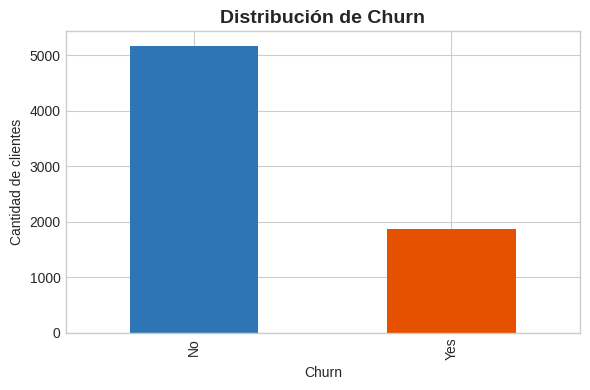

In [ ]:
# Gráfico de barras
fig, ax = plt.subplots(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['#2E75B6', '#E65100'], ax=ax)
ax.set_title('Distribución de Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()


**Pregunta 6:** ¿El dataset está balanceado (las dos clases tienen cantidades similares) o desbalanceado? ¿Qué porcentaje de clientes canceló su contrato? ¿Por qué es importante saber esto antes de entrenar un modelo?

**Respuesta:** El dataset está desbalanceado, ya que hay muchos más clientes que no cancelaron (No) que los que sí cancelaron (Yes). Aproximadamente, el 26.54% de los clientes canceló su contrato, mientras que el 73.46% se mantuvo. Asimismo es importante conocer esto antes de entrenar un modelo porque el desbalance puede hacer que el modelo se sesgue hacia la clase mayoritaria, reduciendo su capacidad para detectar correctamente a los clientes que cancelan (churn).

###Paso 5: Visualización exploratoria
Genera las siguientes visualizaciones para explorar relaciones en los datos:


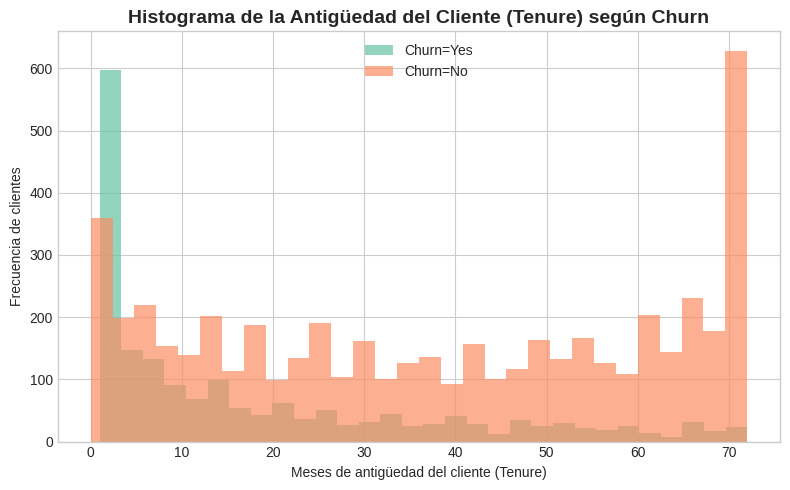

In [ ]:
# Histograma de tenure por Churn
fig, ax = plt.subplots(figsize=(8, 5))
df[df['Churn']=='Yes']['tenure'].hist(alpha=0.7, label='Churn=Yes', bins=30, ax=ax)
df[df['Churn']=='No']['tenure'].hist(alpha=0.7, label='Churn=No', bins=30, ax=ax)
ax.set_title('Histograma de la Antigüedad del Cliente (Tenure) según Churn',fontsize=14, fontweight='bold')
ax.set_xlabel('Meses de antigüedad del cliente (Tenure)')
ax.legend()
ax.set_ylabel('Frecuencia de clientes')
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Cargo mensual (MonthlyCharges)')

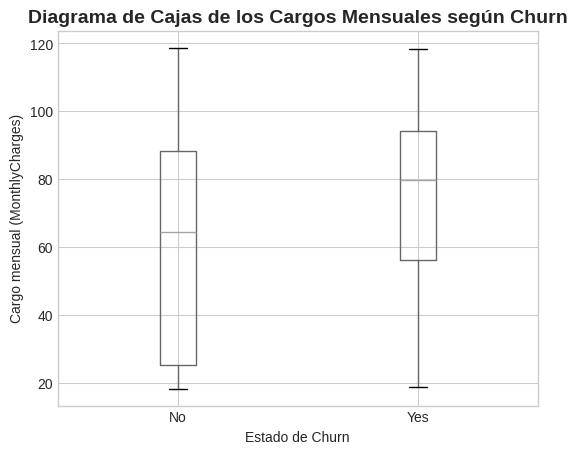

In [ ]:
# Diagrama de cajas de MonthlyCharges por Churn
fig, ax = plt.subplots(figsize=(6, 5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax)
ax.set_title('Diagrama de Cajas de los Cargos Mensuales según Churn',
             fontsize=14, fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Estado de Churn')
ax.set_ylabel('Cargo mensual (MonthlyCharges)')


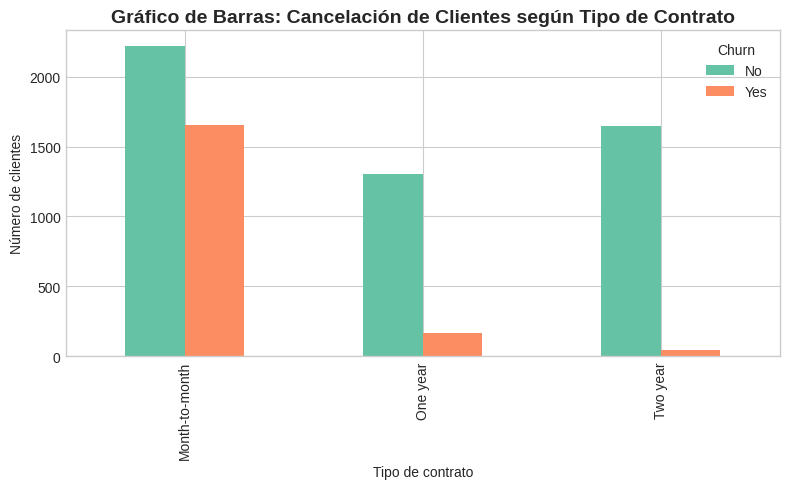

In [ ]:
# Churn por tipo de contrato
fig, ax = plt.subplots(figsize=(8, 5))
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', ax=ax)
ax.set_title('Gráfico de Barras: Cancelación de Clientes según Tipo de Contrato',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de contrato')
ax.set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()


**Pregunta 7:** Observando el histograma de tenure: ¿Los clientes que cancelan tienden a tener más o menos antigüedad? ¿Qué hipótesis podrías formular?

**Respuesta:** Los clientes que cancelan tienden a tener menor antigüedad (tenure). La mayoría de los casos de churn se concentran en los primeros meses.

Hipótesis: los clientes nuevos son más propensos a cancelar porque aún no están fidelizados o no están satisfechos con el servicio inicial.

**Pregunta 8:** Observando el boxplot de MonthlyCharges: ¿Los clientes que cancelan pagan más o menos por mes? ¿Qué podría explicar esto?

**Respuesta:** Los clientes que cancelan tienden a pagar cargos mensuales más altos, esto podría explicarse porque los precios elevados generan mayor insatisfacción o porque estos clientes tienen más servicios, lo que aumenta el costo y la probabilidad de cancelar.

**Pregunta 9:** ¿Qué tipo de contrato tiene mayor tasa de churn? ¿Por qué tiene sentido desde el punto de vista del negocio?

**Respuesta:** El tipo de contrato con mayor churn es Month-to-month.
Esto tiene sentido porque estos clientes no tienen compromiso a largo plazo y pueden cancelar fácilmente en cualquier momento, a diferencia de los contratos anuales o de dos años que generan mayor retención.

###Paso 6: Matriz de correlación
Genera una matriz de correlación para las variables numéricas:


In [ ]:
# Seleccionar solo variables numéricas (incluye Churn_num)
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()


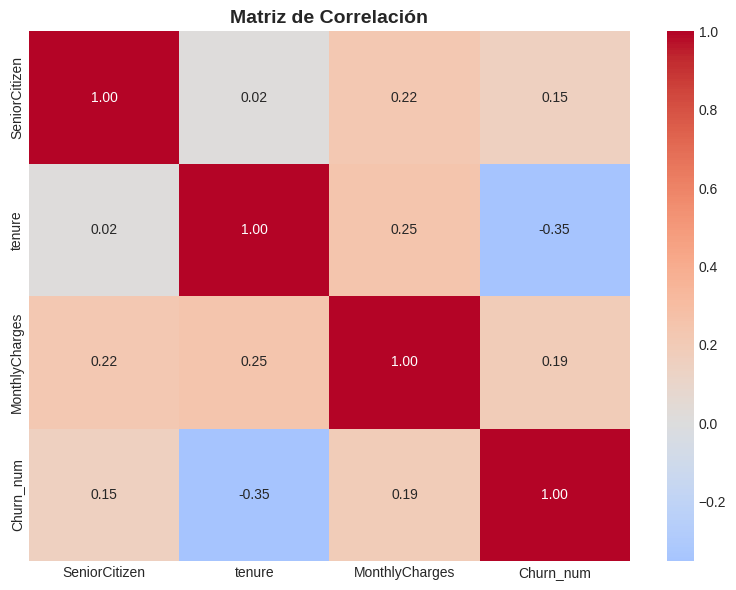

In [ ]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Pregunta 10:** ¿Qué variables muestran mayor correlación con Churn_num?
¿La relación es positiva o negativa? ¿Qué interpretación de negocio puedes hacer?

**Respuesta:** La variable que muestra mayor correlación con Churn_num es tenure, con una correlación negativa (-0.35), lo que indica que mientras mayor es la antigüedad del cliente, menor es la probabilidad de que cancele.

También se observa una correlación positiva débil con MonthlyCharges (0.19) y SeniorCitizen (0.15), lo que sugiere que clientes con mayores cargos mensuales o adultos mayores tienen una ligera mayor probabilidad de cancelar.

Por otro lado, se podria interpretar que los clientes nuevos son más propensos a abandonar el servicio, mientras que los clientes antiguos tienden a ser más leales. Además, precios más altos podrían influir en la decisión de cancelación.

##Actividad 3: Caso de estudio — Análisis para la toma de decisiones

###Contexto del caso:

Eres analista de datos junior en TelcoPerú, una empresa de telecomunicaciones. Tu jefe te ha pedido un informe preliminar sobre la situación del churn de clientes. Aún no vas a construir modelos predictivos (eso vendrá en semanas posteriores), pero necesitas presentar los hallazgos de tu exploración inicial para que el equipo de negocio tome decisiones.
Entregable esperado: Responde las siguientes preguntas en celdas de texto (Markdown) de tu notebook de Colab.


**Pregunta A:** ¿Este problema de negocio (predecir churn) es de clasificación, regresión o clustering? Justifica tu respuesta.

**Respuesta:** Este problema es de clasificación, ya que se busca predecir una variable categórica (Churn) que tiene dos valores posibles: Yes o No. Es decir, el modelo debe clasificar a los clientes según si cancelarán o no el servicio.


**Pregunta B:** Basado en tu exploración, ¿cuáles son las 3 variables que consideras más importantes para predecir el churn? Justifica con los gráficos que generaste.

**Respuesta:**

Las 3 variables más importantes para predecir el churn son:

* tenure: porque los clientes con menor antigüedad tienen mayor probabilidad de cancelar (según el histograma y la correlación negativa).

* MonthlyCharges: los clientes que pagan más tienden a cancelar más (observado en el boxplot).

* Contract: los contratos mensuales presentan mayor churn en comparación con contratos anuales o de dos años (según el gráfico de barras).

**Pregunta C:** ¿Qué fase del proceso KDD acabas de realizar en este laboratorio? Describe brevemente cada paso que seguiste.

**Respuesta:**

La fase realizada corresponde a la Exploración y Comprensión de los Datos (EDA) dentro del proceso KDD. Los pasos realizados fueron:

1. Selección de datos: uso del dataset de clientes.

2. Limpieza de datos: conversión de TotalCharges a numérico y manejo de valores nulos.

3. Transformación de datos: creación de la variable Churn_num.

4. Exploración de datos: análisis estadístico, visualizaciones y correlaciones para entender patrones.

**Pregunta D:** Si fueras a construir un modelo predictivo (en semanas futuras), ¿sería aprendizaje supervisado o no supervisado? ¿Por qué?

**Respuesta:** Sería un problema de aprendizaje supervisado, porque se cuenta con una variable objetivo un Churn previamente etiquetada. El modelo aprenderá a partir de estos datos para predecir el comportamiento de nuevos clientes.

**Pregunta E:** Escribe 3 recomendaciones de negocio para TelcoPerú basadas únicamente en lo que observaste en los datos. No necesitas modelos, solo tus observaciones.

**Respuesta:**

1. Implementar estrategias de fidelización para clientes nuevos, especialmente en sus primeros meses.

2. Revisar la estructura de precios o beneficios, ya que los clientes con mayores cargos mensuales tienden a cancelar más.

3. Promover contratos de largo plazo (anuales o de dos años) para reducir la tasa de cancelación.

##Conclusiones

* La antigüedad del cliente (tenure) es un factor clave en la retención, mostrando una relación inversa con el churn.

* El dataset presenta desbalance en la variable objetivo, lo cual es importante considerar para futuros modelos predictivos.

* El análisis exploratorio permite identificar patrones importantes sin necesidad de modelos, facilitando la toma de decisiones iniciales.

###Reflexión antes del test:

A simple vista, los clientes con Churn=Yes parecen tener menos antigüedad. Pero necesitamos demostrarlo con un test estadistico.
¿Por qué NO usamos el test t de Student aquí?
El test t asume que los datos siguen una distribución normal. Veamos si eso se cumple:

In [ ]:
# Reemplazar espacios vacíos por NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Convertir a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# (Opcional) eliminar nulos
df = df.dropna(subset=['TotalCharges'])

In [ ]:
# Calcular asimetría (skewness) de las variables numéricas
# Regla: si | skewness| > 0.5 > la distribución NO es simétrica + no usar t-Student

print('Asimetría (skewness) de variables numéricas:')
print('-' * 45)

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    skew = df[col].skew()
    normal = '✔ Simétrica' if abs(skew) < 0.5 else '✘ Asimétrica (usar Mann-Whitney)'
    print(f'{col:<20} skewness = {skew:+.3f} {normal}')

Asimetría (skewness) de variables numéricas:
---------------------------------------------
tenure               skewness = +0.238 ✔ Simétrica
MonthlyCharges       skewness = -0.222 ✔ Simétrica
TotalCharges         skewness = +0.962 ✘ Asimétrica (usar Mann-Whitney)


##HIPÓTESIS PARA TotalCharge
      Hipótesis nula (H₀): La distribución de la variable (por ejemplo, TotalCharges) es igual para los clientes que cancelan (Churn = Yes) y los que no cancelan (Churn = No).
      No existe diferencia en el comportamiento del gasto total entre los clientes que se van y los que se quedan.

      Hipótesis alternativa (H₁): La distribución de la variable (por ejemplo, TotalCharges) es diferente entre los clientes que cancelan y los que no cancelan.
      Sí existe una diferencia en el comportamiento del gasto total entre los clientes que se van y los que permanecen, lo que indica que esta variable está asociada al churn.
    pvalor=0.000 <0.05. Se rechaza Ho. Existe evidencia estadística para rechazar la nula, por lo tanto, sí existe una diferencia en el comportamiento del gasto total entre los clientes que se van y los que permanecen, lo que indica que esta variable está asociada al churn.


##HIPÓTESIS PARA TERNURE
    H₀ (Hipótesis nula): La distribución de la antigüedad (tenure) es igual entre los clientes que cancelan (Churn = Yes) y los que no cancelan (Churn = No).
    No existe diferencia en el tiempo de permanencia entre los clientes que se van y los que se quedan.

    H₁ (Hipótesis alternativa): La distribución de la antigüedad (tenure) es diferente entre los clientes que cancelan y los que no cancelan.
    Los clientes que cancelan tienen un comportamiento distinto en su antigüedad, lo que indica que el tiempo en la empresa influye en el churn.

**Pregunta 1 :** ¿Qué significa que una variable tenga asimetría positiva
(skewness > 0)? ¿Qué dice eso sobre la forma de su distribución?

**Respuesta:** Una asimetría positiva (skewness > 0) significa que la distribución está sesgada hacia la derecha, es decir, tiene una cola más larga en los valores altos. Esto indica que la mayoría de los datos se concentran en valores bajos o medios, pero existen algunos valores grandes que alargan la distribución hacia la derecha.

---
## Paso 2: Test de Mann-Whitney U — Variables numéricas

### ¿Qué es el test Mann-Whitney U?

Es un test **no paramétrico**: no requiere que los datos sean normales. Compara si la distribución de una variable es diferente entre **dos grupos independientes**.

| Elemento | Descripción |
|---|---|
| **H₀ (hipótesis nula)** | La distribución de la variable es IGUAL en ambos grupos |
| **H₁ (hipótesis alternativa)** | Existen diferencias entre los grupos |
| **p-value < 0.05** | Rechazamos H₀ → la diferencia es estadísticamente real |
| **p-value ≥ 0.05** | No podemos rechazar H₀ → no hay evidencia suficiente |

> 💡 **Para entenderlo:** Si el p-value es 0.001, significa que la probabilidad de observar esta diferencia por puro azar es del 0.1%. Casi imposible. La diferencia es real.

In [36]:
import scipy.stats as stats

# Separar los dos grupos
grupo_churn_si = df[df['Churn'] == 'Yes']
grupo_churn_no = df[df['Churn'] == 'No']

print('TEST DE MANN-WHITNEY U')
print('H₀: La distribución es igual en ambos grupos')
print('Nivel de significancia: α = 0.05')
print('─' * 70)
print(f'{"Variable":<20} {"Media Churn=Sí":>15} {"Media Churn=No":>15} {"p-value":>12} {"Conclusión"}')
print('─' * 70)

resultados_mw = {}

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    g1 = grupo_churn_si[col].dropna()
    g2 = grupo_churn_no[col].dropna()

    stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    resultados_mw[col] = pval

    conclusion = '✓ DIFERENCIA REAL' if pval < 0.05 else '✗ Sin diferencia'
    print(f'{col:<20} {g1.mean():>15.2f} {g2.mean():>15.2f} {pval:>12.6f}  {conclusion}')

TEST DE MANN-WHITNEY U
H₀: La distribución es igual en ambos grupos
Nivel de significancia: α = 0.05
──────────────────────────────────────────────────────────────────────
Variable              Media Churn=Sí  Media Churn=No      p-value Conclusión
──────────────────────────────────────────────────────────────────────
tenure                         17.98           37.65     0.000000  ✓ DIFERENCIA REAL
MonthlyCharges                 74.44           61.31     0.000000  ✓ DIFERENCIA REAL
TotalCharges                 1531.80         2555.34     0.000000  ✓ DIFERENCIA REAL


##HIPÓTESIS PARA MONTHLYCHARGES
    La hipótesis nula (H₀) indica que no hay diferencias entre los grupos. Los clientes que cancelan y los que no cancelan tienen el mismo comportamiento en una variable como MonthlyCharges.
    La hipótesis alternativa (H₁) indica que si hay diferencias entre los grupos. Los clientes que cancelan y los que no cancelan tienen el mismo comportamiento en una variable como MonthlyCharges.

    Pvalor=0.000 Se rechaza Ho. indica que si hay diferencias entre los grupos. Los clientes que cancelan y los que no cancelan tienen el mismo comportamiento en una variable como MonthlyCharges.

    Similar las hipótesis para los demás grupos

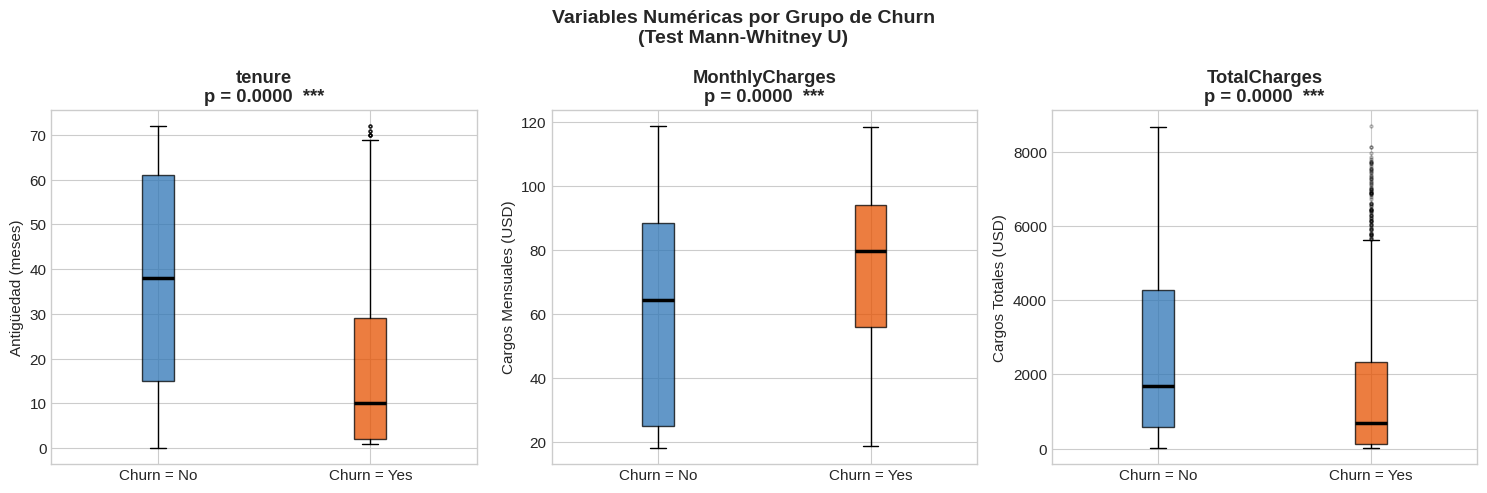

In [ ]:
# Visualización: boxplots con resultado del test incorporado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Variables Numéricas por Grupo de Churn\n(Test Mann-Whitney U)',
             fontsize=14, fontweight='bold')

labels_ejes = ['Antigüedad (meses)', 'Cargos Mensuales (USD)', 'Cargos Totales (USD)']

# Define COLORES_CHURN here
COLORES_CHURN = {'No': '#2E75B6', 'Yes': '#E65100'}

for i, (col, label) in enumerate(zip(['tenure', 'MonthlyCharges', 'TotalCharges'], labels_ejes)):
    datos = [grupo_churn_no[col].dropna(), grupo_churn_si[col].dropna()]
    bp = axes[i].boxplot(datos, patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2.5},
                         flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
    for patch, color in zip(bp['boxes'], [COLORES_CHURN['No'], COLORES_CHURN['Yes']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    pval = resultados_mw[col]
    estrellas = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    axes[i].set_title(f'{col}\np = {pval:.4f}  {estrellas}', fontweight='bold')
    axes[i].set_xticklabels(['Churn = No', 'Churn = Yes'])
    axes[i].set_ylabel(label)

plt.tight_layout()
plt.show()

    Variable: tenure (antigüedad)
    H₀ (Hipótesis nula):La distribución de la antigüedad (tenure) es igual entre los clientes que cancelan (Churn = Yes) y los que no cancelan (Churn = No).
    No hay diferencia en el tiempo de permanencia entre ambos grupos.

    H₁ (Hipótesis alternativa):La distribución de la antigüedad (tenure) es diferente entre los clientes que cancelan y los que no cancelan.
    Los clientes que cancelan tienen una antigüedad distinta (menor), lo que influye en el churn.

    Variable: MonthlyCharges (cargo mensual)
    H₀ (Hipótesis nula):La distribución de los cargos mensuales (MonthlyCharges) es igual entre los clientes que cancelan y los que no cancelan.
    No hay diferencia en lo que pagan mensualmente ambos grupos.

    H₁ (Hipótesis alternativa):La distribución de los cargos mensuales (MonthlyCharges) es diferente entre los clientes que cancelan y los que no cancelan.
    Los clientes que cancelan pagan diferente (generalmente más), lo que influye en su decisión de irse.

    Variable: TotalCharges (gasto total acumulado)
    H₀ (Hipótesis nula):La distribución del gasto total (TotalCharges) es igual entre los clientes que cancelan y los que no cancelan.


    No hay diferencia en el gasto acumulado entre ambos grupos.

    H₁ (Hipótesis alternativa):La distribución del gasto total (TotalCharges) es diferente entre los clientes que cancelan y los que no cancelan.

    Los clientes que cancelan tienen menor gasto acumulado, lo que refleja menor permanencia o compromiso.

**Pregunta 2:** Para la variable `tenure`, el p-value es menor a 0.001. ¿Qué conclusión puedes sacar? Redacta la conclusión completa mencionando H₀, el p-value y lo que significa en términos de negocio.

**Respuesta:**

H₀: No existen diferencias en tenure entre clientes que cancelan y los que no.

H₁: Sí existen diferencias en tenure.

Como el p-value < 0.001, se rechaza H₀ y se acepta H₁.
En negocio: los clientes que hacen churn tienen menor antigüedad, por lo que los clientes nuevos son más propensos a irse.

---

**Pregunta:** `MonthlyCharges` también tiene diferencia significativa. ¿Los clientes que cancelan pagan más o menos mensualmente? ¿Tiene sentido desde la perspectiva del negocio?

**Respuesta:**  Los clientes que cancelan (churn = Yes) pagan más mensualmente.
Sí tiene sentido debido que mientras los precios sean más altos pueden generar mayor insatisfacción, aumentando la probabilidad de cancelación.

-
## Paso 3: Test Chi-cuadrado y V de Cramér — Variables categóricas

Para variables categóricas no podemos usar Mann-Whitney. Usamos el **test Chi-cuadrado de independencia**.

### ¿Qué mide cada indicador?

| Indicador | ¿Qué responde? | Escala |
|---|---|---|
| **Chi-cuadrado (χ²)** | ¿Existe asociación? (sí/no) | p-value: 0 a 1 |
| **V de Cramér** | ¿Qué tan fuerte es esa asociación? | 0 = nula, 1 = perfecta |

> 💡 **¿Por qué necesitamos la V de Cramér?** El chi-cuadrado solo dice si existe relación. Con 7,000 datos, casi cualquier diferencia pequeña será "significativa". La V de Cramér nos dice si esa relación es además **fuerte o débil**.

In [37]:
from scipy.stats import chi2_contingency

# Función para calcular V de Cramér
def cramers_v(tabla_contingencia):
    chi2, pval, dof, expected = chi2_contingency(tabla_contingencia)
    n = tabla_contingencia.sum().sum()
    min_dim = min(tabla_contingencia.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    return chi2, pval, v

# Variables categóricas a analizar
variables_cat = [
    'Contract', 'InternetService', 'PaymentMethod',
    'TechSupport', 'OnlineSecurity', 'PaperlessBilling',
    'gender', 'Partner', 'Dependents', 'SeniorCitizen'
]

print('TEST CHI-CUADRADO + V DE CRAMÉR')
print('H₀: La variable categórica es independiente de Churn')
print('─' * 65)
print(f'{"Variable":<22} {"Chi²":>10} {"p-value":>12} {"V Cramér":>10} {"Asociación"}')
print('─' * 65)

resultados_chi2 = {}

for col in variables_cat:
    tabla = pd.crosstab(df[col], df['Churn'])
    chi2, pval, v = cramers_v(tabla)
    resultados_chi2[col] = {'chi2': chi2, 'pval': pval, 'v': v}

    if   v >= 0.3: fuerza = 'Fuerte'
    elif v >= 0.1: fuerza = 'Moderada'
    else:          fuerza = 'Débil'

    sig = '✓' if pval < 0.05 else '✗'
    print(f'{col:<22} {chi2:>10.2f} {pval:>12.6f} {v:>10.4f}  {sig} {fuerza}')

TEST CHI-CUADRADO + V DE CRAMÉR
H₀: La variable categórica es independiente de Churn
─────────────────────────────────────────────────────────────────
Variable                     Chi²      p-value   V Cramér Asociación
─────────────────────────────────────────────────────────────────
Contract                  1179.55     0.000000     0.4096  ✓ Fuerte
InternetService            728.70     0.000000     0.3219  ✓ Fuerte
PaymentMethod              645.43     0.000000     0.3030  ✓ Fuerte
TechSupport                824.93     0.000000     0.3425  ✓ Fuerte
OnlineSecurity             846.68     0.000000     0.3470  ✓ Fuerte
PaperlessBilling           256.87     0.000000     0.1911  ✓ Moderada
gender                       0.48     0.490488     0.0082  ✗ Débil
Partner                    157.50     0.000000     0.1497  ✓ Moderada
Dependents                 186.32     0.000000     0.1628  ✓ Moderada
SeniorCitizen              158.44     0.000000     0.1501  ✓ Moderada


    PaperlessBilling (No tributa)
    Partner (Tiene pareja)
    Dependents (Tiene dependientes)
    SeniorCitizen (Adulto mayor)

    H₀ (hipótesis nula): La variable categórica es independiente a la cancelación del cliente (churn)
    H₁ (hipótesis alternativa):La variable categórica sí está asociada a la cancelación del cliente (churn)

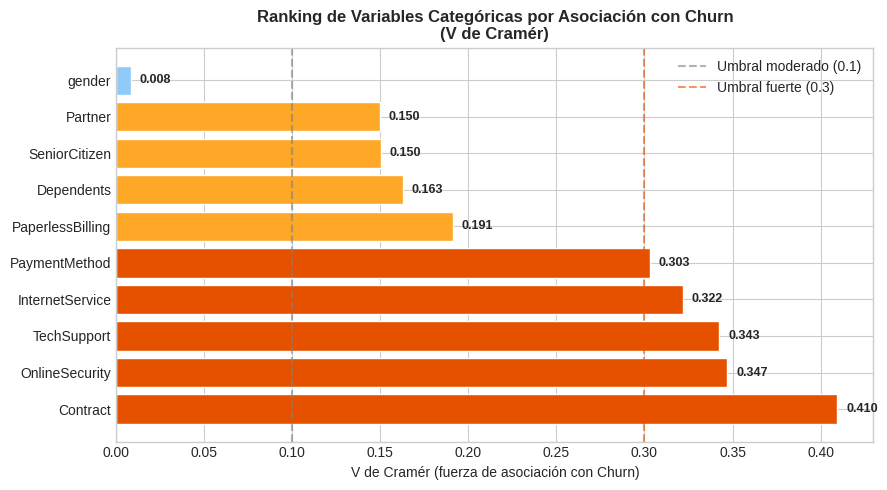

In [38]:
# Ranking visual de variables por V de Cramér
ranking = sorted(resultados_chi2.items(), key=lambda x: x[1]['v'], reverse=True)
vars_orden = [r[0] for r in ranking]
vals_v     = [r[1]['v'] for r in ranking]

colores_barra = ['#E65100' if v >= 0.3 else '#FFA726' if v >= 0.1 else '#90CAF9'
                 for v in vals_v]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(vars_orden, vals_v, color=colores_barra, edgecolor='white')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.6, label='Umbral moderado (0.1)')
ax.axvline(x=0.3, color='#E65100', linestyle='--', alpha=0.6, label='Umbral fuerte (0.3)')
ax.set_xlabel('V de Cramér (fuerza de asociación con Churn)')
ax.set_title('Ranking de Variables Categóricas por Asociación con Churn\n(V de Cramér)',
             fontweight='bold')
ax.legend(frameon=False)
for bar, val in zip(bars, vals_v):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Pregunta 4:** ¿Qué variable categórica tiene la asociación más fuerte con Churn? ¿Y la más débil? ¿Por qué crees que `gender` tiene una V de Cramér tan baja?

**Respuesta 4:** La variable con asociación más fuerte es Contract (V ≈ 0.41) y la más débil es gender (V ≈ 0.008) gender tiene una V tan baja porque prácticamente no hay diferencia real entre hombres y mujeres respecto al churn, es decir, no influye en la cancelación.

---

**Pregunta 5:** Un estudiante dice: *"Chi-cuadrado de `gender` tiene p-value < 0.05, entonces el género sí está asociado al churn"*. ¿Está en lo correcto? ¿Qué le responderías con lo que aprendiste sobre la V de Cramér?

**Respuesta 5:** No necesariamente está en lo correcto. Aunque el p-value < 0.05 indica que hay relación estadística, la V de Cramér es muy baja (~0.008), lo que significa que la fuerza de la asociación es casi nula.
Es decir, puede ser significativo por el tamaño de la muestra, pero en la práctica no es relevante para el negocio.

### Ahora tú: Formula y verifica tu propia hipótesis

Elige **una variable** del dataset que creas que está relacionada con el churn y formula una hipótesis.

**Variables disponibles para explorar:**
`OnlineSecurity`, `InternetService`, `PaperlessBilling`, `PaymentMethod`, `Dependents`, `Partner`, `SeniorCitizen`

---

**Mi hipótesis:**
> *"Los clientes que OnlineSecurity tienen menor tasa de churn que los que no tienen."*

**Justificación (antes de ver los datos):** _¿Por qué crees que esto podría ser cierto?

Porque los clientes con seguridad online perciben mayor valor y protección en el servicio, lo que aumenta su satisfacción y reduce la probabilidad de cancelar.

---
## Paso 7: Matriz de correlación — Detección de multicolinealidad

La matriz de correlación nos permite ver dos cosas importantes:
1. Qué variables numéricas están más relacionadas con **Churn_num** (útil para el modelo)
2. Qué variables están muy relacionadas **entre sí** (problema de multicolinealidad)

**Pregunta 10:** `tenure` y `TotalCharges` tienen correlación r = 0.83. Si fueras a construir un modelo predictivo, ¿incluirías ambas variables o solo una? ¿Cuál elegirías y por qué?

**Respuesta 10:** No incluiría ambas variables porque tienen alta correlación (r = 0.83), lo que genera multicolinealidad. Elegiría tenure, porque es una variable más directa y fácil de interpretar en el negocio (antigüedad del cliente), mientras que TotalCharges depende de tenure y los cargos mensuales.

---

**Pregunta 11:** `tenure` tiene correlación negativa con `Churn_num` (r = -0.35). ¿Qué significa que la correlación sea negativa en este contexto de negocio?

**Respuesta 11:** Que la correlación sea negativa (r = -0.35) significa que a mayor tenure, menor probabilidad de churn. En negocio: los clientes con más tiempo en la empresa son más leales y menos propensos a cancelar.

---
## Actividad Final: Síntesis — Informe para el equipo de negocio

**Contexto:** Eres analista de datos en TelcoPerú. El gerente de retención de clientes te pide un resumen ejecutivo basado en el análisis que acabas de realizar. Él no sabe estadística, pero necesita tomar decisiones esta semana.

Responde las siguientes preguntas **sin usar términos técnicos que él no entendería** (nada de p-value, Mann-Whitney o chi-cuadrado). Solo hallazgos claros y accionables.

---

**Pregunta A:** Resume en 3 puntos concretos quién es el cliente con mayor riesgo de abandonar la empresa (perfil de riesgo).

**Respuesta A:**
1. Clientes nuevos (poco tiempo en la empresa).
2. Clientes con pagos mensuales altos.
3. Clientes con contratos mensuales (sin compromiso a largo plazo).

---

**Pregunta B:** El gerente dice: *"Si solo puedo hacer UNA cosa esta semana para reducir el churn, ¿qué me recomiendas?"* ¿Qué le responderías basándote en los datos?

**Respuesta B:** Enfocarse en los clientes nuevos con contrato mensual, ofreciéndoles incentivos (descuentos o beneficios) para que se queden más tiempo desde el inicio.

---

**Pregunta C:** ¿Qué tipo de problema de Machine Learning es predecir el churn: clasificación, regresión o clustering? ¿Por qué? ¿Cuál sería la variable objetivo (target) y cuáles serían las variables predictoras (features) más prometedoras según tu análisis?

**Respuesta C:** Es un problema de clasificación, porque queremos predecir si un cliente va a cancelar o no.

* Variable objetivo: Churn
* Variables más importantes: tenure, Contract, MonthlyCharges, OnlineSecurity

---

**Pregunta D:** El dataset tiene un 73.5% de clientes que NO cancelaron y solo un 26.5% que sí cancelaron. Si construimos un modelo que siempre predice "No Churn", ¿qué accuracy tendría? ¿Por qué ese modelo sería inútil para la empresa?

**Respuesta D:** Tendría un 73.5% de accuracy, porque la mayoría no cancela. Pero sería inútil porque no identifica a los clientes que sí se van, que son justamente los que la empresa quiere retener.

---

**Pregunta E (desafío):** Propón una variable nueva que NO está en el dataset pero que crees que ayudaría mucho a predecir el churn. Justifica por qué.

**Respuesta E:** Una variable útil sería el nivel de satisfacción del cliente (por ejemplo, encuestas o reclamos).
Esto ayudaría porque clientes insatisfechos tienen mayor probabilidad de cancelar.